# 08. 평가 - RAG 시스템 정량 평가

## 평가 프레임워크

### 질문 유형 (5가지)
| 유형 | 평가 기준 | 설명 |
|---|---|---|
| A. 단일 문서 정확 추출 | 추출 정밀성 | 특정 RFP에서 수치/요구사항을 정확히 추출하는가 |
| B. 다문서 비교/종합 | 정보 통합력 | 여러 RFP를 대조하여 차이점을 요약하는가 |
| C. 후속 질문/대화 맥락 | 문맥 유지력 | 이전 대화 맥락을 유지하여 답변하는가 |
| D. 무응답/안전 응답 | 근거 기반 답변 | 문서에 없는 내용에 대해 거부하는가 |
| E. 모호한 질의 | 검색 견고성 | 부정확한 입력에도 올바른 문서를 찾는가 |

### 평가 단계 (4단계)
| 단계 | 지표 | 방법 |
|---|---|---|
| 검색 | Hit Rate@5, MRR, nDCG@5 | 자동 계산 (정답 매핑) |
| 검색->생성 | Context Precision/Recall | LLM-as-a-Judge |
| 생성 | Faithfulness (3단계), Answer Relevance | LLM-as-a-Judge |
| 성능 | Latency, Token Cost (유형별) | 로그 분석 |

> **Input**: `artifacts/chroma_db/` + `data/processed/chunks.parquet`  
> **Output**: 평가 지표 + 대시보드  
> **Prev**: [07_generation.ipynb](07_generation.ipynb) | **Next**: -


In [17]:
import pandas as pd
import numpy as np
import json
import time
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI
import chromadb

load_dotenv()
openai_client = OpenAI()

In [18]:
ARTIFACTS_DIR = Path("../../artifacts")
CHROMA_DIR = ARTIFACTS_DIR / "chroma_db"
EMBEDDING_MODEL = "text-embedding-3-small"
LLM_MODEL = "gpt-5-mini"
COLLECTION_NAME = "rfp_chunks_v1"

chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))
collection = chroma_client.get_collection(COLLECTION_NAME)
print(f"컬렉션: {collection.count():,}개 청크")

컬렉션: 13,951개 청크


## 1. 07번 RAG 파이프라인 로딩

In [19]:
# 발주기관/사업명 목록
chunks_df = pd.read_parquet(Path("../../data/processed/chunks.parquet"))
AGENCY_LIST = chunks_df['발주 기관'].unique().tolist()


def embed_query(query):
    return openai_client.embeddings.create(input=query, model=EMBEDDING_MODEL).data[0].embedding


def retrieve(query, k=5, where=None):
    kwargs = {"query_embeddings": [embed_query(query)], "n_results": k}
    if where:
        kwargs["where"] = where
    results = collection.query(**kwargs)
    chunks = []
    for i in range(len(results['ids'][0])):
        chunks.append({
            'score': round(1 - results['distances'][0][i], 4),
            'text': results['documents'][0][i],
            'metadata': results['metadatas'][0][i],
        })
    return chunks


DOMAIN_KEYWORDS = {
    '교육/학습': ['교육', '학습', '이러닝', '학사', 'LMS', '연수', '대학'],
    '안전/재난': ['안전', '재난', '방재', '관제', '선량', '방사선'],
    '웹/포털': ['홈페이지', '포털', '웹', '온라인서비스'],
    '경영/행정': ['ERP', '그룹웨어', '경영', '인사', '회계', '오피스'],
    '공간정보/GIS': ['GIS', '지도', '공간정보', '측량', '수문'],
    '의료/바이오': ['의료', '건강', '바이오', '병원', '보험'],
    'ISP/컨설팅': ['ISP', '전략', '컨설팅', '타당성'],
    'AI/데이터': ['AI', '인공지능', '빅데이터', '머신러닝'],
    '교통/물류': ['버스', '교통', 'BIS', 'ITS'],
    '농축수산': ['축산', '농업', '수산', '어촌'],
    '문화/콘텐츠': ['문화', '예술', '박물관', '아카이브'],
    '복지/사회서비스': ['복지', '돌봄', '사회보험', '서민금융'],
}

AGENCY_TYPE_KEYWORDS = {
    '대학교': ['대학', '학교'],
    '공기업/준정부기관': ['공사', '공단', '진흥원'],
    '지방자치단체': ['시청', '군청', '구청', '지자체'],
    '연구기관': ['연구원', '연구소'],
}


def extract_filters(query, chat_history=None):
    release_keywords = ['다른 기관', '다른 사업', '그 외', '외에', '이외', '말고']
    if any(kw in query for kw in release_keywords):
        return None
    where = {}
    matched = []
    for agency in AGENCY_LIST:
        short = agency.replace('(주)', '').replace('㈜', '').strip()
        for part in [short, short[:6], short[:4]]:
            if len(part) >= 3 and part in query:
                if agency not in matched:
                    matched.append(agency)
                break
    if len(matched) >= 2:
        return None
    if len(matched) == 1:
        return {'발주기관': matched[0]}
    for domain, keywords in DOMAIN_KEYWORDS.items():
        if any(kw in query for kw in keywords):
            where['사업도메인'] = domain
            break
    if '사업도메인' not in where:
        for atype, keywords in AGENCY_TYPE_KEYWORDS.items():
            if any(kw in query for kw in keywords):
                where['기관유형'] = atype
                break
    if where:
        return where
    if chat_history:
        for msg in reversed(chat_history):
            if msg.get('filter'):
                return msg['filter']
    return None



SYSTEM_PROMPT = """당신은 공공입찰 RFP(제안요청서) 분석 전문가입니다.
사용자의 질문에 대해 제공된 RFP 문서 컨텍스트를 기반으로 정확하게 답변합니다.

## 역할
- 입찰메이트 컨설팅 스타트업의 사내 RAG 시스템
- 컨설턴트가 RFP 핵심 정보를 빠르게 파악하도록 지원

## 답변 원칙
1. 반드시 제공된 컨텍스트에 있는 내용만 답변하세요.
2. 컨텍스트에 없는 내용은 "제공된 문서에서 해당 정보를 찾을 수 없습니다"라고 명확히 답변하세요. 추측하지 마세요.
3. 부분적으로만 확인되는 경우 "문서에서 확인된 내용은 다음과 같으며, [X]에 대한 정보는 포함되어 있지 않습니다"로 구분하세요.

## 답변 형식
- 출처를 [사업명 | 발주기관] 형태로 답변 끝에 명시하세요.
- 표 형태의 정보는 마크다운 표 구조를 유지하세요.
- 요구사항 정리 시 구분(기능/성능/보안 등)과 고유번호를 포함하세요.
- 핵심을 먼저 말하고 세부사항을 이어서 설명하세요.

## 질문 유형별 대응
- 단일 문서 질문: 해당 문서의 관련 섹션을 구조적으로 정리
- 다문서 비교: 항목을 행으로, 문서를 열로 배치하여 하나의 표로 간결하게 비교
- 후속 질문: 이전 대화 맥락을 참고하되, 현재 컨텍스트 기반으로 답변
- 존재하지 않는 정보: 찾을 수 없다고 답하고 관련 유사 정보가 있으면 안내"""


def build_context(chunks, max_chars=8000):
    parts, total = [], 0
    for c in chunks:
        source = f"[출처: {c['metadata']['사업명']} | {c['metadata']['발주기관']}]"
        chunk_text = f"{source}\n{c['text']}"
        if total + len(chunk_text) > max_chars:
            break
        parts.append(chunk_text)
        total += len(chunk_text)
    return "\n\n---\n\n".join(parts)


def rag_query(query, chat_history=None, k=5):
    start = time.time()
    where = extract_filters(query, chat_history)
    chunks = retrieve(query, k=k, where=where)
    context = build_context(chunks)
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    if chat_history:
        for msg in chat_history[-4:]:
            messages.append({"role": "user", "content": msg["user"]})
            messages.append({"role": "assistant", "content": msg["assistant"]})
    messages.append({"role": "user", "content": f"""다음 RFP 문서 내용을 참고하여 질문에 답변해주세요.\n\n## 참고 문서\n{context}\n\n## 질문\n{query}"""})
    response = openai_client.chat.completions.create(model=LLM_MODEL, messages=messages, max_completion_tokens=8000)
    answer = response.choices[0].message.content or '(응답 없음)'
    elapsed = time.time() - start
    return {
        "query": query, "answer": answer, "filter": where,
        "chunks": chunks, "context_chars": len(context),
        "elapsed_sec": round(elapsed, 1),
        "tokens": {"prompt": response.usage.prompt_tokens, "completion": response.usage.completion_tokens, "total": response.usage.total_tokens},
    }

print("RAG 파이프라인 로딩 완료")

RAG 파이프라인 로딩 완료


## 2. 평가셋 정의

5가지 유형별 질문 + 기대 정답 문서 + ground truth 키워드를 정의합니다.

In [20]:
eval_set = [
    # A. 단일 문서 정확 추출
    {"id": "A1", "type": "A", "query": "국민연금공단이 발주한 이러닝시스템 관련 사업 요구사항을 정리해 줘",
     "expected_docs": ["이러닝시스템 운영 용역"], "expected_agency": "국민연금공단",
     "ground_truth_keywords": ["FUR-001", "SFR-001", "DER-001", "교육운영", "콘텐츠"]},
    
    {"id": "A2", "type": "A", "query": "한국 원자력 연구원에서 선량 평가 시스템 고도화 사업의 목적을 알려 줘",
     "expected_docs": ["선량평가시스템 고도화"], "expected_agency": "한국원자력연구원",
     "ground_truth_keywords": ["규제", "ICRP60", "액체유출물", "K-RADAC", "UI 개선"]},
    
    {"id": "A3", "type": "A", "query": "봉화군 재난통합관리시스템 고도화 사업의 사업 범위를 알려줘",
     "expected_docs": ["재난통합관리시스템 고도화"], "expected_agency": "경상북도 봉화군",
     "ground_truth_keywords": ["GIS", "계측", "관측", "재난예경보", "통합상황전파"]},
    
    # B. 다문서 비교/종합
    {"id": "B1", "type": "B", "query": "고려대학교 차세대 포털 시스템 사업이랑 광주과학기술원의 학사 시스템 기능개선 사업을 비교해 줄래?",
     "expected_docs": ["차세대 포털", "학사시스템 기능개선"], "expected_agency": None,
     "ground_truth_keywords": ["고려대학교", "광주과학기술원", "사업기간", "예산"]},
    
    {"id": "B2", "type": "B", "query": "고려대학교랑 광주과학기술원 각각 응답 시간에 대한 요구사항이 있나?",
     "expected_docs": ["차세대 포털", "학사시스템 기능개선"], "expected_agency": None,
     "ground_truth_keywords": ["응답", "시간", "성능"]},
    
    # C. 후속 질문 (2턴 대화)
    {"id": "C1", "type": "C", "query": "콘텐츠 개발 관리 요구 사항에 대해서 더 자세히 알려 줘",
     "prereq": {"query": "국민연금공단이 발주한 이러닝시스템 관련 사업 요구사항을 정리해 줘"},
     "expected_docs": ["이러닝시스템 운영 용역"], "expected_agency": "국민연금공단",
     "ground_truth_keywords": ["DER-001", "콘텐츠 개발", "60차시", "검수"]},
    
    {"id": "C2", "type": "C", "query": "교육이나 학습 관련해서 다른 기관이 발주한 사업은 없나?",
     "prereq": {"query": "국민연금공단이 발주한 이러닝시스템 관련 사업 요구사항을 정리해 줘"},
     "expected_docs": [],  # 다른 기관이므로 국민연금 외 문서
     "expected_agency": None,
     "ground_truth_keywords": ["교육", "학습"]},
    
    {"id": "C3", "type": "C", "query": "그럼 모니터링 업무에 대한 요청사항이 있는지 찾아보고 알려 줘",
     "prereq": {"query": "기초과학연구원 극저온시스템 사업 요구에서 AI 기반 예측에 대한 요구사항이 있나?"},
     "expected_docs": ["극저온시스템 운전 용역"], "expected_agency": "기초과학연구원",
     "ground_truth_keywords": ["알람", "센서", "트렌드", "모니터링"]},
    
    # D. 무응답/안전 응답
    {"id": "D1", "type": "D", "query": "국민연금공단 이러닝시스템 사업의 낙찰 업체가 어디야?",
     "expected_docs": ["이러닝시스템 운영 용역"], "expected_agency": "국민연금공단",
     "ground_truth_keywords": ["찾을 수 없"],
     "should_refuse": True},
    
    {"id": "D2", "type": "D", "query": "2025년 서울시 AI 챗봇 구축 사업에 대해 알려줘",
     "expected_docs": [], "expected_agency": None,
     "ground_truth_keywords": ["찾을 수 없"],
     "should_refuse": True},
    
    # E. 모호한 질의
    {"id": "E1", "type": "E", "query": "기초과학연구원 극저온시스템 사업 요구에서 AI 기반 예측에 대한 요구사항이 있나?",
     "expected_docs": ["극저온시스템 운전 용역"], "expected_agency": "기초과학연구원",
     "ground_truth_keywords": ["찾을 수 없", "모니터링", "알람"]},
    
    {"id": "E2", "type": "E", "query": "교육 관련 시스템 사업 중에 예산이 가장 큰 거는 뭐야?",
     "expected_docs": [], "expected_agency": None,
     "ground_truth_keywords": ["교육", "예산"]},
]

print(f"평가셋: {len(eval_set)}개 질문")
type_counts = pd.Series([q['type'] for q in eval_set]).value_counts().sort_index()
display(type_counts.to_frame('질문 수').rename_axis('유형'))

평가셋: 12개 질문


,질문 수
유형,
A,3
B,2
C,3
D,2
E,2


## 3. 검색 지표 계산 함수

In [21]:
def calc_hit_rate(chunks, expected_docs, k=5):
    """Top-k에 기대 문서가 하나라도 포함되었는지."""
    if not expected_docs:
        return None
    top_k_docs = [c['metadata']['사업명'] for c in chunks[:k]]
    for exp in expected_docs:
        if any(exp in doc for doc in top_k_docs):
            return 1.0
    return 0.0


def calc_mrr(chunks, expected_docs):
    """첫 번째 정답 문서의 역순위. 1위=1.0, 2위=0.5, ..."""
    if not expected_docs:
        return None
    for i, c in enumerate(chunks):
        doc_name = c['metadata']['사업명']
        if any(exp in doc_name for exp in expected_docs):
            return 1.0 / (i + 1)
    return 0.0


def calc_ndcg(chunks, expected_docs, k=5):
    """nDCG@k: 관련 문서의 순위 품질.
    
    관련도: 2 = 정확히 기대 문서, 1 = 같은 기관, 0 = 무관
    """
    if not expected_docs:
        return None
    
    # 실제 관련도
    relevances = []
    for c in chunks[:k]:
        doc_name = c['metadata']['사업명']
        if any(exp in doc_name for exp in expected_docs):
            relevances.append(2)  # 정확 매칭
        else:
            relevances.append(0)
    
    # DCG
    dcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(relevances))
    
    # 이상적 순위 (모든 관련 문서가 맨 위)
    ideal = sorted(relevances, reverse=True)
    idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal))
    
    return dcg / idcg if idcg > 0 else 0.0


print("검색 지표 함수 정의 완료")

검색 지표 함수 정의 완료


## 4. LLM-as-a-Judge 함수

In [22]:
JUDGE_PROMPT = """당신은 RAG 시스템의 답변 품질을 평가하는 전문 평가자입니다.
아래 질문, 검색된 컨텍스트, 생성된 답변을 보고 각 항목을 채점하세요.

## 채점 항목 (각 0~2점)
- faithfulness: 답변이 컨텍스트에만 기반했는가? (2=완전 문서기반, 1=일부 해석, 0=할루시네이션)
- relevance: 질문 의도에 맞는 답변인가? (2=정확 대응, 1=부분 대응, 0=무관)
- context_precision: 검색된 청크가 질문에 관련되는가? (2=대부분 관련, 1=일부만, 0=무관)
- context_recall: 답변에 필요한 정보가 컨텍스트에 충분한가? (2=충분, 1=일부 누락, 0=대부분 누락)

## 채점 예시
질문: '사업 예산을 알려줘' / 답변이 정확한 금액을 인용 -> {"faithfulness":2,"relevance":2,"context_precision":2,"context_recall":2,"reasoning":"정확한 금액 인용"}
질문: 'AI 요구사항이 있나?' / 답변이 '없다'고 정직하게 답변 -> {"faithfulness":2,"relevance":2,"context_precision":1,"context_recall":2,"reasoning":"문서에 없음을 정확히 판단"}
질문: '비교해줘' / 한쪽 문서만 답변 -> {"faithfulness":2,"relevance":1,"context_precision":1,"context_recall":1,"reasoning":"한쪽만 비교"}

반드시 JSON만 출력하세요. 다른 텍스트 없이 JSON 하나만 출력하세요."""


def llm_judge(query, context, answer):
    """LLM-as-a-Judge로 답변 품질을 채점한다. Few-Shot + 강화 파싱."""
    user_msg = f"""질문: {query}\n\n컨텍스트(요약): {context[:2000]}\n\n답변: {answer[:2000]}\n\nJSON만 출력:"""
    
    for attempt in range(2):  # 최대 2회 시도
        try:
            response = openai_client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {"role": "system", "content": JUDGE_PROMPT},
                    {"role": "user", "content": user_msg},
                ],
                max_completion_tokens=16000,
            )
            raw = response.choices[0].message.content.strip()
            
            # JSON 추출 (여러 패턴 시도)
            import re
            # 패턴 1: 순수 JSON
            if raw.startswith('{'):
                return json.loads(raw)
            # 패턴 2: 텍스트 안에 JSON
            match = re.search(r'\{[^}]+\}', raw)
            if match:
                return json.loads(match.group())
            # 패턴 3: 코드블록 안에 JSON
            match = re.search(r'```(?:json)?\s*(\{[^}]+\})', raw)
            if match:
                return json.loads(match.group(1))
        except Exception as e:
            if attempt == 0:
                continue  # 재시도
            print(f"  Judge 실패 (2회): {str(e)[:60]}")
    
    return {"faithfulness": -1, "relevance": -1, "context_precision": -1, "context_recall": -1, "reasoning": "평가 실패"}


print("LLM Judge 함수 정의 완료 (Few-Shot + 재시도)")


LLM Judge 함수 정의 완료 (Few-Shot + 재시도)


## 5. 전체 평가 실행

In [23]:
REFUSE_PATTERNS = ['찾을 수 없', '확인할 수 없', '포함되어 있지 않', '해당 정보를 찾을 수 없', '해당 정보가 없']

eval_results = []

for q in eval_set:
    print(f"\n[{q['id']}] {q['query'][:50]}...")
    
    # C유형: 선행 질문 먼저 실행
    chat_history = None
    if q['type'] == 'C' and q.get('prereq'):
        prereq_result = rag_query(q['prereq']['query'])
        chat_history = [{
            "user": q['prereq']['query'],
            "assistant": prereq_result['answer'],
            "filter": prereq_result['filter'],
        }]
    
    # RAG 실행 (필터 자동 추출)
    k = 10 if q['type'] == 'B' else 5
    result = rag_query(q['query'], chat_history=chat_history, k=k)
    
    # 필터 없는 검색도 별도 측정 (순수 벡터 검색 품질)
    raw_chunks = retrieve(q['query'], k=k, where=None)
    raw_hit = calc_hit_rate(raw_chunks, q['expected_docs'])
    raw_mrr = calc_mrr(raw_chunks, q['expected_docs'])
    raw_ndcg = calc_ndcg(raw_chunks, q['expected_docs'])
    
    # 필터 적용 검색 지표
    hit = calc_hit_rate(result['chunks'], q['expected_docs'])
    mrr = calc_mrr(result['chunks'], q['expected_docs'])
    ndcg = calc_ndcg(result['chunks'], q['expected_docs'])
    
    # Ground truth 키워드 매칭
    keyword_hits = sum(1 for kw in q['ground_truth_keywords'] if kw in result['answer'])
    keyword_rate = keyword_hits / len(q['ground_truth_keywords']) if q['ground_truth_keywords'] else 0
    
    # LLM Judge
    judge = llm_judge(q['query'], build_context(result['chunks']), result['answer'])
    
    # D유형: 거부 여부 (확장 패턴)
    refused = any(p in result['answer'] for p in REFUSE_PATTERNS) if q.get('should_refuse') else None
    
    eval_results.append({
        'id': q['id'], 'type': q['type'], 'query': q['query'][:40],
        # 필터 적용 검색
        'hit_rate': hit, 'mrr': mrr, 'ndcg': ndcg,
        # 필터 없는 검색 (순수 벡터)
        'raw_hit': raw_hit, 'raw_mrr': raw_mrr, 'raw_ndcg': raw_ndcg,
        # 생성 품질
        'keyword_rate': round(keyword_rate, 2),
        'faithfulness': judge.get('faithfulness', -1),
        'relevance': judge.get('relevance', -1),
        'ctx_precision': judge.get('context_precision', -1),
        'ctx_recall': judge.get('context_recall', -1),
        'refused': refused,
        'elapsed_sec': result['elapsed_sec'],
        'tokens_total': result['tokens']['total'],
        'judge_reasoning': judge.get('reasoning', ''),
    })
    
    filt_str = f"HR={hit} MRR={mrr:.2f} nDCG={ndcg:.2f}" if hit is not None else "(정답없음)"
    raw_str = f"raw_HR={raw_hit} raw_MRR={raw_mrr:.2f}" if raw_hit is not None else ""
    print(f"  필터검색: {filt_str} | 벡터검색: {raw_str}")
    print(f"  KW={keyword_rate:.0%} | Judge: F={judge.get('faithfulness')} R={judge.get('relevance')} CP={judge.get('context_precision')} CR={judge.get('context_recall')} | {result['elapsed_sec']}초")

print(f"\n평가 완료: {len(eval_results)}건")



[A1] 국민연금공단이 발주한 이러닝시스템 관련 사업 요구사항을 정리해 줘...
  필터검색: HR=1.0 MRR=1.00 nDCG=1.00 | 벡터검색: raw_HR=1.0 raw_MRR=1.00
  KW=100% | Judge: F=1 R=2 CP=2 CR=1 | 33.8초

[A2] 한국 원자력 연구원에서 선량 평가 시스템 고도화 사업의 목적을 알려 줘...
  필터검색: HR=1.0 MRR=1.00 nDCG=1.00 | 벡터검색: raw_HR=1.0 raw_MRR=1.00
  KW=100% | Judge: F=2 R=2 CP=2 CR=2 | 12.1초

[A3] 봉화군 재난통합관리시스템 고도화 사업의 사업 범위를 알려줘...
  필터검색: HR=1.0 MRR=1.00 nDCG=1.00 | 벡터검색: raw_HR=1.0 raw_MRR=1.00
  KW=100% | Judge: F=2 R=2 CP=2 CR=2 | 30.0초

[B1] 고려대학교 차세대 포털 시스템 사업이랑 광주과학기술원의 학사 시스템 기능개선 사업을 비교해...
  필터검색: HR=1.0 MRR=1.00 nDCG=1.00 | 벡터검색: raw_HR=1.0 raw_MRR=1.00
  KW=100% | Judge: F=1 R=2 CP=2 CR=1 | 49.3초

[B2] 고려대학교랑 광주과학기술원 각각 응답 시간에 대한 요구사항이 있나?...
  필터검색: HR=1.0 MRR=1.00 nDCG=1.00 | 벡터검색: raw_HR=1.0 raw_MRR=1.00
  KW=100% | Judge: F=1 R=2 CP=1 CR=1 | 20.9초

[C1] 콘텐츠 개발 관리 요구 사항에 대해서 더 자세히 알려 줘...
  필터검색: HR=1.0 MRR=1.00 nDCG=1.00 | 벡터검색: raw_HR=1.0 raw_MRR=0.33
  KW=100% | Judge: F=1 R=2 CP=2 CR=2 | 45.9초

[C2] 교육이나 학습 관련해서 다른 기관이 발주한 사업은 없나?...
  필터검색: 

## 6. 검색 단계 평가 결과

In [24]:
eval_df = pd.DataFrame(eval_results)

retrieval_df = eval_df[eval_df['hit_rate'].notna()].copy()

print("=== 검색 지표: 필터 적용 vs 순수 벡터 ===")
compare_retrieval = pd.DataFrame({
    '지표': ['Hit Rate@5', 'MRR', 'nDCG@5'],
    '필터 적용': [
        f"{retrieval_df['hit_rate'].mean():.2f}",
        f"{retrieval_df['mrr'].mean():.2f}",
        f"{retrieval_df['ndcg'].mean():.2f}",
    ],
    '순수 벡터': [
        f"{retrieval_df['raw_hit'].mean():.2f}",
        f"{retrieval_df['raw_mrr'].mean():.2f}",
        f"{retrieval_df['raw_ndcg'].mean():.2f}",
    ],
}).set_index('지표')
display(compare_retrieval)

print("\n=== 질문별 검색 지표 (필터 vs 벡터) ===")
display(retrieval_df[['id', 'type', 'query', 'hit_rate', 'mrr', 'ndcg', 'raw_hit', 'raw_mrr', 'raw_ndcg']].round(2))


=== 검색 지표: 필터 적용 vs 순수 벡터 ===


,필터 적용,순수 벡터
지표,,
Hit Rate@5,1.00,0.78
MRR,1.00,0.70
nDCG@5,1.00,0.73



=== 질문별 검색 지표 (필터 vs 벡터) ===


,id,type,query,hit_rate,mrr,ndcg,raw_hit,raw_mrr,raw_ndcg
0,A1,A,국민연금공단이 발주한 이러닝시스템 관련 사업 요구사항을 정리해 줘,1.0,1.0,1.0,1.0,1.00,1.00
1,A2,A,한국 원자력 연구원에서 선량 평가 시스템 고도화 사업의 목적을 알려 줘,1.0,1.0,1.0,1.0,1.00,1.00
2,A3,A,봉화군 재난통합관리시스템 고도화 사업의 사업 범위를 알려줘,1.0,1.0,1.0,1.0,1.00,1.00
3,B1,B,고려대학교 차세대 포털 시스템 사업이랑 광주과학기술원의 학사 시스템 기능,1.0,1.0,1.0,1.0,1.00,1.00
4,B2,B,고려대학교랑 광주과학기술원 각각 응답 시간에 대한 요구사항이 있나?,1.0,1.0,1.0,1.0,1.00,1.00
5,C1,C,콘텐츠 개발 관리 요구 사항에 대해서 더 자세히 알려 줘,1.0,1.0,1.0,1.0,0.33,0.57
7,C3,C,그럼 모니터링 업무에 대한 요청사항이 있는지 찾아보고 알려 줘,1.0,1.0,1.0,0.0,0.00,0.00
8,D1,D,국민연금공단 이러닝시스템 사업의 낙찰 업체가 어디야?,1.0,1.0,1.0,1.0,1.00,1.00
10,E1,E,기초과학연구원 극저온시스템 사업 요구에서 AI 기반 예측에 대한 요구사항,1.0,1.0,1.0,0.0,0.00,0.00


In [25]:
# 유형별 검색 지표
print("=== 유형별 검색 지표 평균 ===")
type_retrieval = retrieval_df.groupby('type')[['hit_rate', 'mrr', 'ndcg']].mean().round(2)
display(type_retrieval)

=== 유형별 검색 지표 평균 ===


,hit_rate,mrr,ndcg
type,,,
A,1.0,1.0,1.0
B,1.0,1.0,1.0
C,1.0,1.0,1.0
D,1.0,1.0,1.0
E,1.0,1.0,1.0


## 7. 생성 단계 평가 결과 (LLM Judge)

In [26]:
judge_cols = ['faithfulness', 'relevance', 'ctx_precision', 'ctx_recall']
valid_judge = eval_df[eval_df['faithfulness'] >= 0]

print("=== LLM Judge 전체 평균 (0~2점 스케일) ===")
judge_summary = valid_judge[judge_cols].mean().round(2).to_frame('평균')
judge_summary['100점 환산'] = (judge_summary['평균'] / 2 * 100).round(0)
display(judge_summary)

print("\n=== 질문별 LLM Judge ===")
display(eval_df[['id', 'type', 'query', 'faithfulness', 'relevance', 'ctx_precision', 'ctx_recall', 'judge_reasoning']])

=== LLM Judge 전체 평균 (0~2점 스케일) ===


,평균,100점 환산
faithfulness,1.42,71.0
relevance,2.00,100.0
ctx_precision,1.75,88.0
ctx_recall,1.58,79.0



=== 질문별 LLM Judge ===


,id,type,query,faithfulness,relevance,ctx_precision,ctx_recall,judge_reasoning
0,A1,A,국민연금공단이 발주한 이러닝시스템 관련 사업 요구사항을 정리해 줘,1,2,2,1,"응답은 질문 의도(이러닝시스템 요구사항 정리)에 부합하지만, 제시된 컨텍스트 요약에..."
1,A2,A,한국 원자력 연구원에서 선량 평가 시스템 고도화 사업의 목적을 알려 줘,2,2,2,2,"답변은 제공된 문서의 내용(1.2 추진배경: 규제요건 및 액체유출물 필요, 업무생산..."
2,A3,A,봉화군 재난통합관리시스템 고도화 사업의 사업 범위를 알려줘,2,2,2,2,답변은 제공된 문서의 항목들을 충실히 요약·정리함. 사업 범위를 3개 분야(재난통합...
3,B1,B,고려대학교 차세대 포털 시스템 사업이랑 광주과학기술원의 학사 시스템 기능,1,2,2,1,"답변은 비교 요청 의도에 잘 부합하여 GIST 문서의 주요 항목(예산 157,300..."
4,B2,B,고려대학교랑 광주과학기술원 각각 응답 시간에 대한 요구사항이 있나?,1,2,1,1,광주과학기술원에 대한 '평균 응답시간 3초 이내 및 예외(통계/배치/2GB 이상 제...
5,C1,C,콘텐츠 개발 관리 요구 사항에 대해서 더 자세히 알려 줘,1,2,2,2,"답변은 문서의 주요 항목(DER-001, DER-002, MAR-001, MAR-0..."
6,C2,C,교육이나 학습 관련해서 다른 기관이 발주한 사업은 없나?,0,2,2,2,답변은 질문 의도(다른 발주기관의 교육·학습 관련 사업 존재 여부)에 정확히 응답하...
7,C3,C,그럼 모니터링 업무에 대한 요청사항이 있는지 찾아보고 알려 줘,1,2,2,2,답변은 문서의 3.4.2~3.4.4 내용을 대체로 충실히 요약하여 모니터링 항목(알...
8,D1,D,국민연금공단 이러닝시스템 사업의 낙찰 업체가 어디야?,2,2,2,2,"제공된 문서는 입찰공고 및 제안요청서 양식(입찰참가신청서, 제안서 서식 등)으로 구..."
9,D2,D,2025년 서울시 AI 챗봇 구축 사업에 대해 알려줘,2,2,0,0,제공된 문서는 '2025 구미아시아육상경기선수권대회 종합정보시스템' 관련 요구사항(...


In [27]:
# 유형별 Judge 평균
print("=== 유형별 LLM Judge 평균 ===")
type_judge = valid_judge.groupby('type')[judge_cols].mean().round(2)
display(type_judge)

=== 유형별 LLM Judge 평균 ===


,faithfulness,relevance,ctx_precision,ctx_recall
type,,,,
A,1.67,2.0,2.0,1.67
B,1.00,2.0,1.5,1.00
C,0.67,2.0,2.0,2.00
D,2.00,2.0,1.0,1.00
E,2.00,2.0,2.0,2.00


## 8. 무응답 평가 (D유형)

In [28]:
d_type = eval_df[eval_df['type'] == 'D']
refuse_rate = d_type['refused'].mean()

print(f"=== D유형 무응답 정확도: {refuse_rate:.0%} ({d_type['refused'].sum()}/{len(d_type)}) ===")
display(d_type[['id', 'query', 'refused', 'keyword_rate']])

=== D유형 무응답 정확도: 100% (2/2) ===


,id,query,refused,keyword_rate
8,D1,국민연금공단 이러닝시스템 사업의 낙찰 업체가 어디야?,True,1.0
9,D2,2025년 서울시 AI 챗봇 구축 사업에 대해 알려줘,True,1.0


## 9. 성능 지표 (유형별)

In [29]:
print("=== 유형별 성능 ===")
perf = eval_df.groupby('type').agg(
    평균_응답시간=('elapsed_sec', 'mean'),
    평균_토큰=('tokens_total', 'mean'),
    질문수=('id', 'count'),
).round(1)
display(perf)

# 전체 평균
print(f"\n전체 평균: {eval_df['elapsed_sec'].mean():.1f}초, {eval_df['tokens_total'].mean():.0f}토큰/질문")

=== 유형별 성능 ===


,평균_응답시간,평균_토큰,질문수
type,,,
A,25.3,4263.7,3
B,35.1,7351.0,2
C,32.1,6676.0,3
D,11.5,3733.5,2
E,17.8,3903.0,2



전체 평균: 25.1초, 5233토큰/질문


## 10. 종합 대시보드

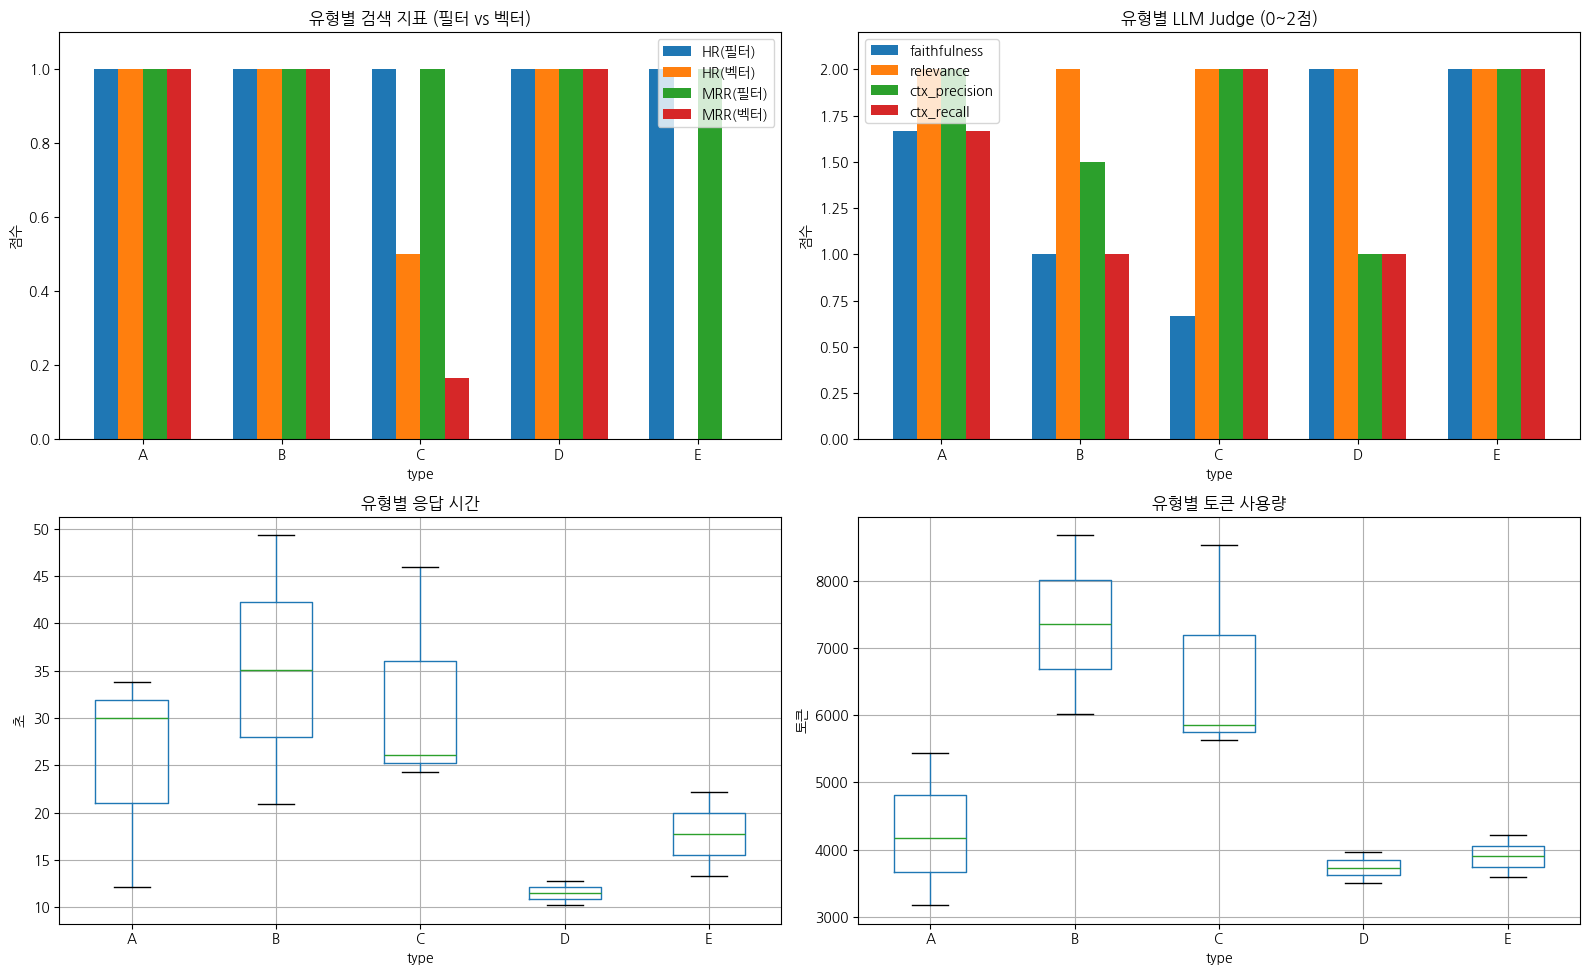

In [30]:
import koreanize_matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) 유형별 검색 지표 (필터 적용 vs 순수 벡터)
ax = axes[0, 0]
r_df = eval_df[eval_df['hit_rate'].notna()]
if len(r_df) > 0:
    compare = r_df.groupby('type')[['hit_rate', 'raw_hit', 'mrr', 'raw_mrr']].mean()
    compare.columns = ['HR(필터)', 'HR(벡터)', 'MRR(필터)', 'MRR(벡터)']
    compare.plot.bar(ax=ax, width=0.7)
ax.set_title('유형별 검색 지표 (필터 vs 벡터)')
ax.set_ylabel('점수')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=0)

# 2) 유형별 LLM Judge (실패 제외)
ax = axes[0, 1]
judge_cols = ['faithfulness', 'relevance', 'ctx_precision', 'ctx_recall']
valid = eval_df[eval_df['faithfulness'] >= 0]
if len(valid) > 0:
    type_judge = valid.groupby('type')[judge_cols].mean()
    type_judge.plot.bar(ax=ax, width=0.7)
ax.set_title('유형별 LLM Judge (0~2점)')
ax.set_ylabel('점수')
ax.set_ylim(0, 2.2)
ax.tick_params(axis='x', rotation=0)

# 3) 응답 시간
ax = axes[1, 0]
eval_df.boxplot(column='elapsed_sec', by='type', ax=ax)
ax.set_title('유형별 응답 시간')
ax.set_ylabel('초')
plt.suptitle('')

# 4) 토큰 사용량
ax = axes[1, 1]
eval_df.boxplot(column='tokens_total', by='type', ax=ax)
ax.set_title('유형별 토큰 사용량')
ax.set_ylabel('토큰')
plt.suptitle('')

plt.tight_layout()
plt.show()


## 11. 종합 요약 및 인사이트

### Baseline 평가 결과 (시나리오 B: text-embedding-3-small + gpt-5-mini)

| 단계 | 지표 | 필터 적용 | 순수 벡터 |
|---|---|---|---|
| 검색 | Hit Rate@5 | **1.00** | 0.78 |
| 검색 | MRR | **1.00** | 0.70 |
| 검색 | nDCG@5 | **1.00** | 0.73 |

| 단계 | 지표 | 점수 (0~2) | 100점 환산 |
|---|---|---|---|
| 생성 | Faithfulness (충실도) | 1.42 | **71점** |
| 생성 | Answer Relevance (관련성) | 2.00 | **100점** |
| 전환 | Context Precision (정밀도) | 1.75 | **88점** |
| 전환 | Context Recall (재현율) | 1.58 | **79점** |

| 단계 | 지표 | 결과 |
|---|---|---|
| 무응답 | 거부 정확도 (D유형) | **100%** (2/2) |
| 성능 | 평균 응답 시간 | 25.1초 |
| 성능 | 평균 토큰 사용량 | 5,233토큰/질문 |

### 유형별 강점/약점

| 유형 | Faithfulness | Relevance | 강점 | 약점 |
|---|---|---|---|---|
| A (단일문서) | 1.67 | 2.0 | 정확한 요구사항 표 추출 | 일부 해석 섞임 |
| B (다문서비교) | 1.00 | 2.0 | 비교표 구조화 | 정보 부족 + 해석 |
| C (후속질문) | 0.67 | 2.0 | 맥락 유지 성공 | Faithfulness 최저 |
| D (무응답) | 2.0 | 2.0 | 완벽한 거부 | - |
| E (모호한질의) | 2.0 | 2.0 | 만점 | - |

### 핵심 인사이트

**1. 메타데이터 필터가 검색 성능을 22~30%p 향상시킴**

필터 적용 시 HR/MRR/nDCG 모두 1.0이지만, 순수 벡터만으로는 0.70~0.78.
특히 후속질문(C3)과 모호한질의(E1)에서 벡터만으로는 HR=0.0 (아예 못 찾음).
질문에서 발주기관을 자동 감지하여 필터를 거는 로직이 핵심 성능 요인.

**2. Relevance 100점, Faithfulness 71점 — 답변 형식은 좋지만 충실도 개선 필요**

모든 답변이 질문 의도에 맞지만(Relevance 2.0), 일부 답변에서 컨텍스트 외 해석이 포함됨.
특히 C유형(후속질문)에서 Faithfulness 0.67로 가장 낮음 — 대화 맥락에서 추측이 발생.

**3. B유형(다문서비교)이 가장 취약**

Faithfulness 1.0, Context Recall 1.0으로 전 유형 중 최저.
두 문서를 비교하려면 양쪽 모두 충분한 청크가 필요한데 k=10으로도 부족할 수 있음.

**4. 무응답(D)과 모호한질의(E)는 만점**

프롬프트의 '추측하지 마세요' + '부분 확인 시 구분' 지시가 효과적.
'AI 예측 없음 + 모니터링만 있음' 같은 정직한 부분 확인 답변이 높은 점수 획득.

### 프로젝트 평가 기준과의 매핑

| 프로젝트 평가 기준 | 대응 지표 | 결과 |
|---|---|---|
| 단일 문서에서 정확하게 추출 | A유형 HR=1.0, Faithfulness=1.67 | 양호 |
| 여러 문서를 잘 종합 | B유형 nDCG=1.0, Faithfulness=1.0 | 개선 필요 |
| 후속 질문 맥락 이해 | C유형 KW=100%, Relevance=2.0 | 양호 (충실도 보완) |
| 문서에 없는 내용 거부 | D유형 거부 정확도=100% | 우수 |
| 응답 속도 | 평균 25.1초 | 개선 여지 있음 |

### 고도화 방향 (평가 결과 기반)
| 우선순위 | 대상 | 방법 | 기대 효과 |
|---|---|---|---|
| 1 | Faithfulness 향상 | 프롬프트 추측 금지 강화, 컨텍스트 범위 축소 | C유형 0.67 -> 1.5+ |
| 2 | B유형 Context Recall | k 증가 또는 문서별 별도 검색 | B유형 1.0 -> 1.5+ |
| 3 | 순수 벡터 검색 개선 | Hybrid Search (BM25+벡터) | raw HR 0.78 -> 0.9+ |
| 4 | 시나리오 A 비교 | KURE-v1 임베딩 실험 | 한국어 검색 성능 비교 |
